# Figure 4

This plot analyses the matrices downloaded with Load_Sparse_Suite_Matrices.ipynb, drawing a scatterplot with all matrix densities. 

In [ ]:
import ssgetpy
import scipy
import numpy as np
from tqdm.notebook import tqdm
from scipy.io import mmread
from scipy.sparse import csr_matrix
import os

In [4]:
start_path = "/scratch/gsorrentino/.ssgetpy/MM/"
filename="matrix_file.csv"
count=0
with open(filename, "w") as fd:
    fd.write(f"name,nrow,ncol,nnz,density\n")
    for root, _, files in os.walk(start_path):
        for file in files:
            if file.endswith(".mtx"):
                count = count +1
                matrixpath=os.path.join(root, file)
                name = file.split(".")[0]
                A = mmread(matrixpath)
                B = csr_matrix(A)
                nrow, ncol = A.shape
                nnz = B.count_nonzero()
                if nnz != 0: 
                    d = nnz / (nrow*ncol)
                else: 
                    d = 0
                fd.write(f"{name},{nrow},{ncol},{nnz},{d}\n")

#print(f"Analyses completed : {count} matrices processed")

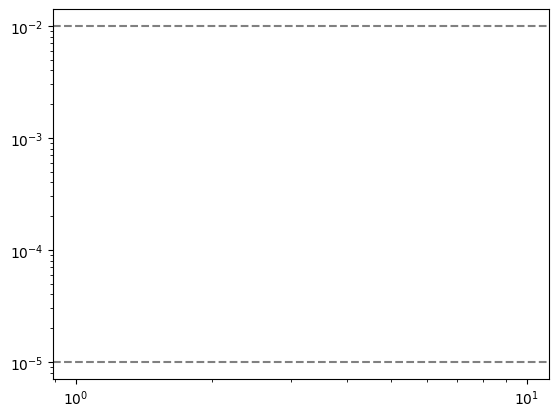

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
data = pd.read_csv(filename)
df = pd.DataFrame(data)

min_bound = 10000
max_bound = 1000000
df = df[(df["nrow"]>min_bound)]
df = df[ df["nrow"]<max_bound]
ax = sns.scatterplot(data=df, x="nrow", y="density", hue="name", legend = False)

line1=0.01
ax.axhline(y=line1, color='gray', linestyle='--')
ax.text(x=df["nrow"].max(), y=line1, s=f"y = {line1}", 
        color='blue', fontsize=12, verticalalignment='top')

line2=0.00001
ax.axhline(y=line2, color='gray', linestyle='--')
ax.text(x=df["nrow"].max(), y=line2, s=f"y = {line2}", 
        color='blue', fontsize=12, verticalalignment='top')
ax.set_yscale('log')
ax.set_xscale('log')
plt.savefig("sparsesuite_scatter.pdf")